### TRAINING THE Hydro-MODEL:

In [1]:
#.......................................................Hydro_Training...............................................#

import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix  
from sklearn.metrics import classification_report 
warnings.filterwarnings(action = 'ignore')
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("./hydro_Data.csv")
df[:] = np.nan_to_num(df)

In [3]:
df[:]

,temperature,turbidity,tds,ph,result
0,15,29,7,9,2
1,15,20,5,8,2
2,34,58,1,14,2
3,37,35,1,9,2
4,30,27,9,4,2
...,...,...,...,...,...
9995,38,40,5,4,2
9996,16,77,10,12,2
9997,17,60,7,9,2
9998,36,41,6,8,2


In [4]:
df[:]['result'].unique()

array([2, 1, 0])

In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df

,temperature,turbidity,tds,ph,result
0,15,29,7,9,2
1,15,20,5,8,2
2,34,58,1,14,2
3,37,35,1,9,2
4,30,27,9,4,2
...,...,...,...,...,...
9995,38,40,5,4,2
9996,16,77,10,12,2
9997,17,60,7,9,2
9998,36,41,6,8,2


In [6]:
df.shape

(10000, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   temperature  10000 non-null  int64
 1   turbidity    10000 non-null  int64
 2   tds          10000 non-null  int64
 3   ph           10000 non-null  int64
 4   result       10000 non-null  int64
dtypes: int64(5)
memory usage: 390.8 KB


In [8]:
df.columns

Index(['temperature', 'turbidity', 'tds', 'ph', 'result'], dtype='object')

In [9]:
df.describe()

,temperature,turbidity,tds,ph,result
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,27.50730,50.088600,6.486100,7.519800,1.836300
std,7.46952,17.637054,3.462254,4.022192,0.414149
min,15.00000,20.000000,1.000000,1.000000,0.000000
25%,21.00000,35.000000,3.000000,4.000000,2.000000
50%,28.00000,50.000000,6.000000,8.000000,2.000000
75%,34.00000,65.000000,10.000000,11.000000,2.000000
max,40.00000,80.000000,12.000000,14.000000,2.000000


In [10]:
df.head(73590)

,temperature,turbidity,tds,ph,result
0,15,29,7,9,2
1,15,20,5,8,2
2,34,58,1,14,2
3,37,35,1,9,2
4,30,27,9,4,2
...,...,...,...,...,...
9995,38,40,5,4,2
9996,16,77,10,12,2
9997,17,60,7,9,2
9998,36,41,6,8,2


In [11]:
df1=df

In [12]:
df1['result'].unique()

array([2, 1, 0])

In [13]:
filter = df1["result"]==1

In [14]:
df1.where(filter)

,temperature,turbidity,tds,ph,result
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
9995,NaN,NaN,NaN,NaN,NaN
9996,NaN,NaN,NaN,NaN,NaN
9997,NaN,NaN,NaN,NaN,NaN
9998,NaN,NaN,NaN,NaN,NaN


In [15]:
df1['result'].value_counts()

result
2    8536
1    1291
0     173
Name: count, dtype: int64

In [16]:
y = df['result'].values
X = df.drop('result', axis=1).values

In [17]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [18]:
X_train

array([[38, 56,  5, 10],
       [24, 73,  8,  5],
       [30, 67,  6, 13],
       ...,
       [17, 50,  6, 13],
       [24, 50,  5,  2],
       [15, 23, 12,  3]], shape=(7000, 4))

In [19]:
knn = KNeighborsClassifier(n_neighbors=6)

In [20]:
knn.fit(X_train,y_train)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = knn.predict(X_test)
print("Prediction : {}".format(y_pred))

Prediction : [2 2 2 ... 2 2 0]


<Figure size 600x500 with 0 Axes>

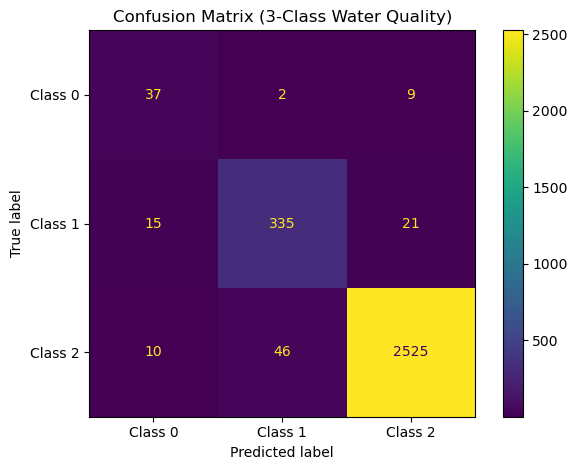

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# y_test and y_pred are original (0/1/2)
labels = [0, 1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0","Class 1","Class 2"])
disp.plot(values_format='d')
plt.title("Confusion Matrix (3-Class Water Quality)")
plt.tight_layout()
plt.savefig("Figure_Confusion_Matrix_3Class.png", dpi=300)
plt.show()


In [22]:
print("Hydro Accuracy:",metrics.accuracy_score(y_test, y_pred)*100)

Hydro Accuracy: 96.56666666666666


In [23]:
joblib.dump(knn,'hydro_model.pkl')

['hydro_model.pkl']

In [24]:
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report :')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[  37    2    9]
 [  15  335   21]
 [  10   46 2525]]
Accuracy Score : 0.9656666666666667
Report :
              precision    recall  f1-score   support

           0       0.60      0.77      0.67        48
           1       0.87      0.90      0.89       371
           2       0.99      0.98      0.98      2581

    accuracy                           0.97      3000
   macro avg       0.82      0.88      0.85      3000
weighted avg       0.97      0.97      0.97      3000



In [25]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

import pandas as pd
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score


In [26]:
dtc =  DecisionTreeClassifier()
rfc = RandomForestClassifier()
knn =  KNeighborsClassifier()


In [27]:
clf = [dtc,rfc,knn]
for algo in clf:
    score = cross_val_score( algo,X_train,y_train,cv = 5,scoring = 'accuracy')
    print("The accuracy score of {} is:".format(algo),score.mean())

The accuracy score of DecisionTreeClassifier() is: 1.0
The accuracy score of RandomForestClassifier() is: 0.9998571428571429
The accuracy score of KNeighborsClassifier() is: 0.9704285714285714


In [28]:
dtc =  DecisionTreeClassifier()
rfc = RandomForestClassifier()
knn =  KNeighborsClassifier()

clf = [('dtc',dtc),('rfc',rfc),('knn',knn)]

In [29]:
clf

[('dtc', DecisionTreeClassifier()),
 ('rfc', RandomForestClassifier()),
 ('knn', KNeighborsClassifier())]

In [30]:
for i in clf:
    print(i[0])
    i[1].fit(X_train,y_train)

dtc
rfc
knn


In [31]:
import joblib
for i in clf:
    filename = ''+i[0]+'.sav'
    joblib.dump(i[1], filename)

In [32]:
p = dtc.predict([X_test[199]])
p=round(abs(p[0]))

print('Predicted: %.3f' % p)

Predicted: 2.000


In [33]:
p = dtc.predict([X_test[100]])
p=round(abs(p[0]))

print('Predicted: %.3f' % p)

Predicted: 2.000


In [34]:
p = dtc.predict([X_test[0]])
p=round(abs(p[0]))

print('Predicted: %.3f' % p)

Predicted: 2.000


In [35]:
core = cross_val_score( dtc,X_train,y_train,cv = 5,scoring = 'accuracy')
print("The accuracy score of {} is:".format(dtc),score.mean())

The accuracy score of DecisionTreeClassifier() is: 0.9704285714285714
